Dataset Loaded Successfully
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural       

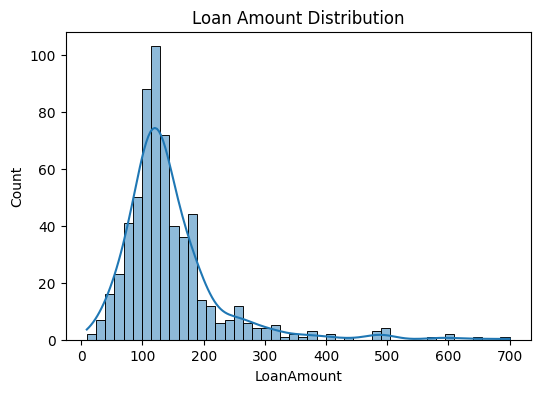

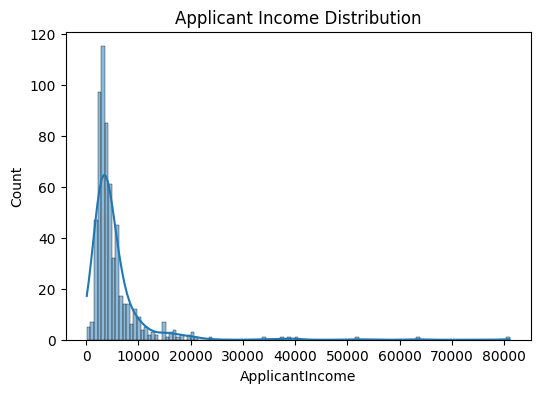

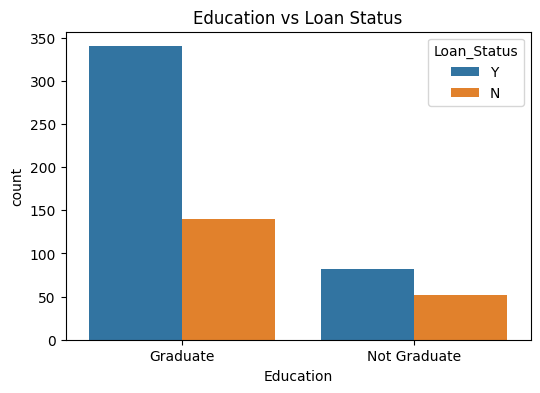


Logistic Regression Accuracy:
0.7886178861788617

Confusion Matrix (Logistic Regression):


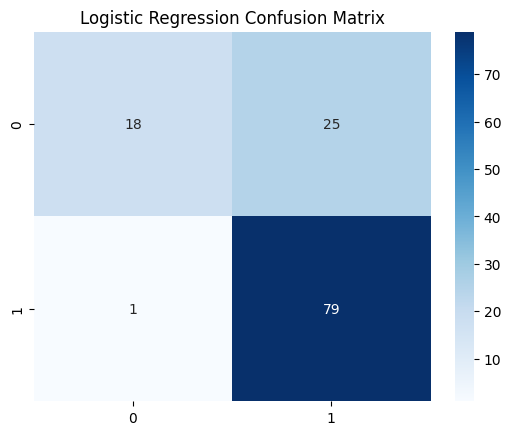


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123


Decision Tree Accuracy:
0.6910569105691057

Confusion Matrix (Decision Tree):


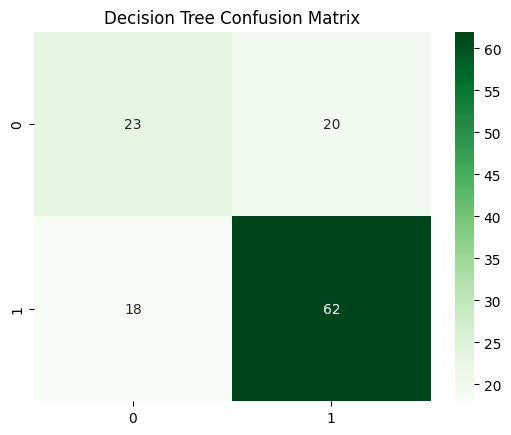


Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.53      0.55        43
           1       0.76      0.78      0.77        80

    accuracy                           0.69       123
   macro avg       0.66      0.65      0.66       123
weighted avg       0.69      0.69      0.69       123



In [7]:
# =====================================================
# CREDIT RISK PREDICTION PROJECT
# Objective: Predict loan default (Loan_Status)
# =====================================================

# ---------------- IMPORT LIBRARIES ----------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---------------- LOAD DATASET ----------------

df = pd.read_csv("loan_data_set.csv")

print("Dataset Loaded Successfully")
print(df.head())

# ---------------- CHECK MISSING VALUES ----------------

print("\nMissing Values:")
print(df.isnull().sum())

# ---------------- HANDLE MISSING DATA ----------------

# Categorical columns (mode)
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Numerical columns (median)
for col in ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# ---------------- EDA (VISUALIZATION) ----------------

# Loan Amount Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['LoanAmount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

# Applicant Income Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title("Applicant Income Distribution")
plt.show()

# Education vs Loan Status
plt.figure(figsize=(6,4))
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title("Education vs Loan Status")
plt.show()

# ---------------- ENCODE CATEGORICAL DATA ----------------

le = LabelEncoder()

categorical_cols = [
    'Gender', 'Married', 'Dependents',
    'Education', 'Self_Employed',
    'Property_Area', 'Loan_Status'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# ---------------- FEATURES & TARGET ----------------

X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status']

# ---------------- TRAIN TEST SPLIT ----------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- FEATURE SCALING (IMPORTANT FIX) ----------------

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =====================================================
# LOGISTIC REGRESSION MODEL
# =====================================================

lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("\nLogistic Regression Accuracy:")
print(accuracy_score(y_test, lr_pred))

print("\nConfusion Matrix (Logistic Regression):")
cm_lr = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

# =====================================================
# DECISION TREE MODEL
# =====================================================

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("\nDecision Tree Accuracy:")
print(accuracy_score(y_test, dt_pred))

print("\nConfusion Matrix (Decision Tree):")
cm_dt = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

